# Freight Rate Assesment
**Objective**: Generate a prediction for "predict_rate" for unseen loads using historical data using a Machine Learning model

## Unit of Analysis

Based on the provided dataset, **each row represents a single freight load (`load_id`) posted on a specific date**, along with its shipment characteristics and the corresponding freight rate (`posted_rate`). The variables are interpreted as follows:

| Variable | Description |
|----------|-------------|
| **load_id** | Unique identifier for each freight load. |
| **pickup** | City where the shipment originates. |
| **delivery** | Destination city for the shipment. |
| **pickup_lat / pickup_lon** | Latitude and longitude of the pickup location. |
| **delivery_lat / delivery_lon** | Latitude and longitude of the delivery location. |
| **distance** | Distance between the pickup and delivery locations. |
| **equipment** | Type of equipment or trailer required to transport the load (e.g., Dry Van, Reefer, Flatbed). |
| **weight** | Weight of the shipment. |
| **date** | Date on which the load was posted. |
| **market_index** | Numerical indicator representing overall freight market conditions at the time the load was posted. |
| **quote_signal** | Numerical pricing-related signal associated with the load. The exact definition is not provided, but it is expected to contain predictive information about the freight rate. |
| **posted_rate** | Observed freight rate (price) for transporting the load. This is the target variable to be predicted. |

In summary, the **unit of analysis** is a **single freight load**, uniquely identified by `load_id`, with features describing the shipment and a target variable (`posted_rate`) representing the freight cost.


## Loading Data

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

train_data = pd.read_csv('data/train-test.csv')
validation_data = pd.read_csv('data/validation.csv')

print(f"Train data shape: {train_data.shape}")
print(f"Validation data shape: {validation_data.shape}")

# Data inspection
print("\n  Train Data Insights:")
train_data.info()
train_data.describe(include='all')
train_data.head()

print("\n Validation Data Insights:")
validation_data.info()
validation_data.describe(include='all')
validation_data.head()

print("\nChecking for negative values in train data:")
cols = ["distance", "weight", "market_index", "quote_signal", "posted_rate"]

(train_data[cols] < 0).sum()


## Important Observations
From the train-test.csv , the 'date' column is stored as an char object and should be converted to a datetime format, the same issue is present in validation.csv.

Two variables, 'weight' and 'market_index' have missing values in the 48000 entries, more specifically 674 entries are missing this values, even though is less than 1% of the the total observations, still should be fixed, the same values are missing in the validation.csv.

Another issue was found in the 'weight' feature where there are negative values,an aspect that is nonsensicial in freight logistics, therfore that is an issue to resolve as well.

There are cities in validation.csv that are not seen in traning: Allentown, Chicago, Charlotte, Norfolk, Knoxville, Jackson , San Diego and Laredo, therefore the pickup/delivery variables should not be taken as primary signals but rather the distance in between the cities.

## Data cleaning


The new (`train_clean`) will be the clean copy of the raw training dataset that will be used for the modeling and development.
1. Removed the observartions with **missing values**
2. Remove observations with **negative** weights
3. Changed the `date` to a datetime type variable

In [ ]:
# Missing values per column
print(train_data.isna().sum())

# Rows with any missing value
missing_rows = train_data.isna().any(axis=1).sum()
print(f"Rows with at least one missing value: {missing_rows}")

# Rows with negative weight
negative_weight = (train_data["weight"] < 0).sum()
print(f"Rows with negative weight: {negative_weight}")

# Create cleaned dataset
train_clean = (
    train_data
    .dropna()
    .query("weight >= 0")
    .copy()
)

# Convert the date column to datetime
train_clean["date"] = pd.to_datetime(train_clean["date"])

# Summary
print(f"Original shape: {train_data.shape}")
print(f"Cleaned shape: {train_clean.shape}")
print(f"Rows dropped: {len(train_data) - len(train_clean)}")

# Verify the conversion
print(train_clean["date"].dtype)

## Exploratory Data Analysis (EDA)


#### Analysis of `posted_rate` 


In [ ]:
train_clean["posted_rate"].describe()

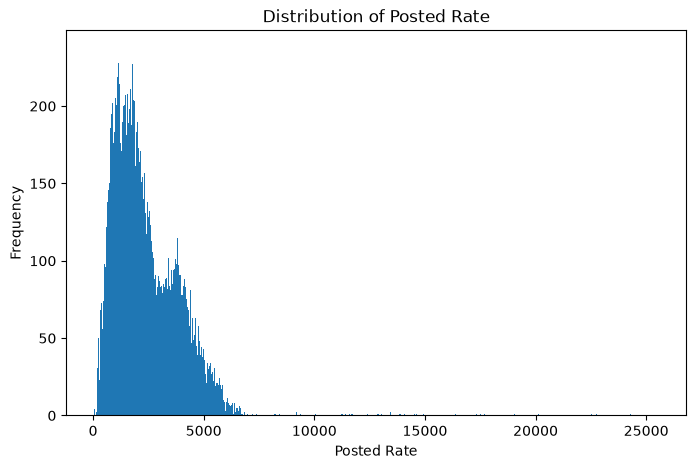

In [ ]:

plt.figure(figsize=(8,5))
plt.hist(train_clean["posted_rate"], bins=2000)
plt.title("Distribution of Posted Rate")
plt.xlabel("Posted Rate")
plt.ylabel("Frequency")
plt.show()

The feature shows us that the majority of freight prices are in the `0 to 5000`range. By using the previous command we also know that the after the 0 to 5000 bracket there are outlier prices going through the `10000 to 25000` bracket, where 25000 is the highest price recorded in the dataset. This aspect gives the variable the right-skewed distribution shape. In the distribuition there are two main frequency peaks, around the `1,000 and 3,000` and a second peak on the `3,500 to 4,500` suggesting two underlying groups of freight prices

#### Relationship with **Numerical variables**

Correlation Matrix

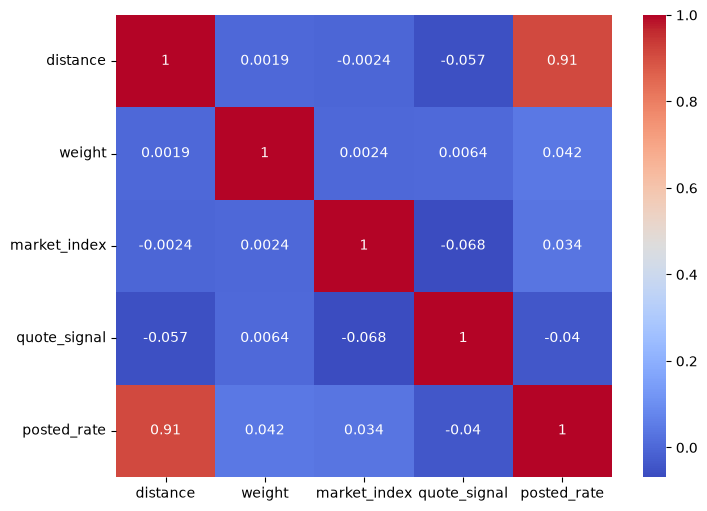

In [5]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    train_clean[
        ["distance","weight","market_index",
         "quote_signal","posted_rate"]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()

The **correlation matrix** describes that distance has the strongest linear relationship with the rate price, with a Pearson correlation coefficent of 0.91 we can safely say that the longer the shipments are the higher the rate will tend to go. Variables like `'weight'`, `market_index`, and `'quote_signal'` show little signs of linear correlation, although a non-linear correlation made with more sophisticated models could still be affecting the rates. Correlation does not indicate **causation**. From this correlation analysis is safe to use the distance as one of our main signals for the ML model.

#### Relationship with **Categorical Variables**

Relationship with the equipment being used to transport the load

In [ ]:
train_clean["equipment"].value_counts()

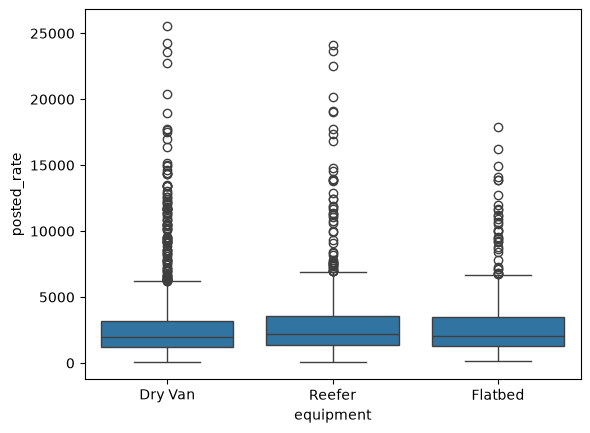

In [ ]:
sns.boxplot(
    data=train_clean,
    x="equipment",
    y="posted_rate"
)
plt.show()

The boxplot tells us that despite the outlliers, the reefer equipment has the highest median posted rate in comparsion with the flatbed and dry van equipment but said difference is relatively small. The outliers indicate that there are other factors, not represented in the equipment type, that may induce the change in rates where dry vans and reefers are used in the highest reported rates whereas the outliers of flatbeds are the lowest rated among the outlier values beyond the 5000 rate in comparison to the other two equipments.

Relationship with **pickup and delivery cities**

In [ ]:
train_clean["pickup"].value_counts().head(20)

In [9]:
lane_stats = (
    train_data
    .groupby(["pickup", "delivery"])
    .agg(
        shipments=("posted_rate", "count"),
        avg_rate=("posted_rate", "mean"),
        avg_market_index=("market_index", "mean")
    )
    .reset_index()
)

lane_stats = lane_stats.sort_values("shipments", ascending=False)
lane_stats.head(10)


,pickup,delivery,shipments,avg_rate,avg_market_index
923,Columbia,Oklahoma City,39,2330.734615,1.084060
3002,Phoenix,Shreveport,39,3507.618462,1.130298
2007,Lexington,Atlanta,39,560.106154,1.134051
1299,Fort Wayne,Philadelphia,38,1681.032632,1.117027
3538,Shreveport,Hartford,37,2867.768108,1.044042
1279,Fort Wayne,Hartford,37,1938.657297,1.052025
3244,Richmond,Oklahoma City,37,3093.435946,1.094949
3246,Richmond,Phoenix,37,5190.194595,1.107940
2034,Lexington,Kansas City,37,1042.474595,1.076781
2017,Lexington,Cincinnati,37,396.691892,1.118951


The busiest freight lanes, identified by the number of posted shipments may not exibit a consistent relationship with the prevalence of a certian destination or delivery zone, so perhaps our best option for relating the posted rate is with the actual distance covered in between the pickup and delivery city.

Relationship with **date**

In [10]:
train_clean["month"] = train_clean["date"].dt.month

train_clean.groupby("month")["posted_rate"].mean()

month
1     2258.385657
2     2273.232855
3     2372.833940
4     2373.498963
5     2419.615031
6     2496.525469
7     2415.655160
8     2337.097114
9     2406.753913
10    2377.284790
Name: posted_rate, dtype: float64

By analyzing the posted rate by month, we can see gradual increase from January to June with a slight decline after the month of June. Throughout the year it varies from aproxximately 2,260 and 2,500 without any evident seasonal pattern. June has the highest posted rate while August has the lowest.